In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### FUNCTIONS ###

def generate_points(mean=[0., 0.], angle_deg=45, lamb=np.array([[100, 0], [0, 1]]), n=100, seed=None):
    """
    Generate random 2D points with covariance structure defined by rotation and lambda matrix.
    """
    if seed is not None:
        np.random.seed(seed)

    angle = angle_deg * math.pi / 180
    rot = np.array([[math.cos(angle), -math.sin(angle)], 
                    [math.sin(angle),  math.cos(angle)]])
    s = np.matmul(rot, np.matmul(lamb, rot.T))
    points = np.random.multivariate_normal(mean, s, n)
    return points


def plot_regression(points, w, outliers=None, title="Linear Regression Fit"):
    """
    Plot dataset and regression line.
    points: Nx2 array of [x, y]
    w: tuple/list (w0, w1)
    outliers: list of indices to highlight
    """
    x = points[:, 0]
    y = points[:, 1]
    y_pred = w[0] * x + w[1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, label='Data points', color='blue', alpha=0.7)

    # Highlight outliers if any
    if outliers is not None:
        plt.scatter(x[outliers], y[outliers], color='red', label='Outliers', s=80, marker='x')

    plt.plot(x, y_pred, color='orange', linewidth=2, label='Fitted line')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


def gradient_descent(points, rho=lambda u: 0.5 * u**2, rho_prime=lambda u: u, 
                     alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent to find w0, w1 minimizing sum of rho(e_i)
    where e_i = w0*x_i + w1 - y_i.

    Parameters:
    - rho, rho_prime: error function and its derivative
    - alpha: learning rate
    - tol: stopping threshold for gradient norm
    - return_residuals: if True, returns (w0, w1, residuals)
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initialize parameters
    w0, w1 = 0.0, 0.0

    for i in range(max_iter):
        y_pred = w0 * x + w1
        e = y_pred - y

        # Compute gradients
        grad_w0 = np.sum(rho_prime(e) * x)
        grad_w1 = np.sum(rho_prime(e))

        grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
        if grad_norm < tol:
            break

        # Update parameters
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1

    if return_residuals:
        return w0, w1, e  # include residuals
    else:
        return w0, w1


def gradient_descent_robust(points, c=1, alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent using the Cauchy robust error function:
    rho(u) = (c^2 / 2) * log(1 + (u / c)^2)
    rho'(u) = u / (1 + (u / c)^2)
    """
    rho = lambda u: 0.5 * (c**2) * np.log(1 + (u / c)**2)
    rho_prime = lambda u: u / (1 + (u / c)**2)

    return gradient_descent(points, rho=rho, rho_prime=rho_prime,
                            alpha=alpha, max_iter=max_iter, tol=tol,
                            return_residuals=return_residuals)


def compare_regression_methods(points, c=1, title_suffix="(no outliers)"):
    """
    Compare Least Squares vs Cauchy Robust regression on the same dataset.
    Fits both models, prints parameters, and plots results.
    """
    # Fit both models
    w_ls = gradient_descent(points)
    w_cauchy = gradient_descent_robust(points, c=c)

    # Print parameters
    print(f"=== Regression Comparison {title_suffix} ===")
    print(f"Least Squares Fit: w0 = {w_ls[0]:.4f}, w1 = {w_ls[1]:.4f}")
    print(f"Cauchy Robust Fit (c={c}): w0 = {w_cauchy[0]:.4f}, w1 = {w_cauchy[1]:.4f}")

    # Plot comparison
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')

    # Compute predicted lines
    y_ls = w_ls[0] * x + w_ls[1]
    y_cauchy = w_cauchy[0] * x + w_cauchy[1]

    # Plot both
    plt.plot(x, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return w_ls, w_cauchy


Least Squares Fit Parameters:
w0 (slope): 0.9659664355531029
w1 (intercept): 0.07510702192147199


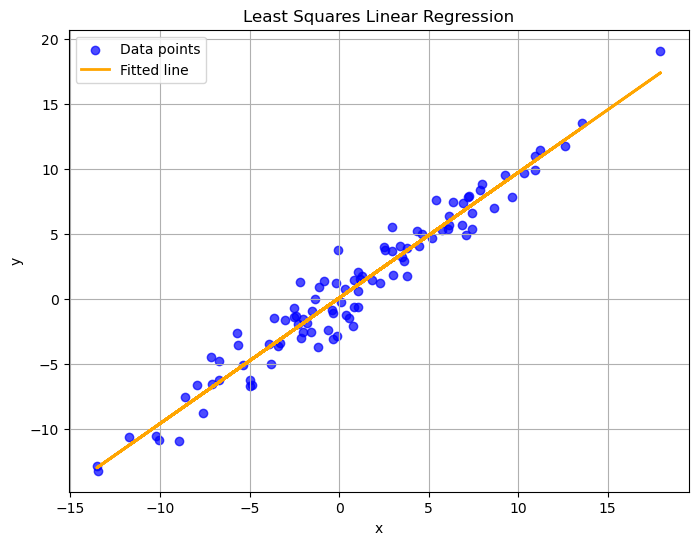

In [2]:
# Generate points
points = generate_points(angle_deg=45, seed=42)

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression")

Least Squares Fit Parameters:
w0 (slope): 0.5222779250220864
w1 (intercept): 0.8541772108284581


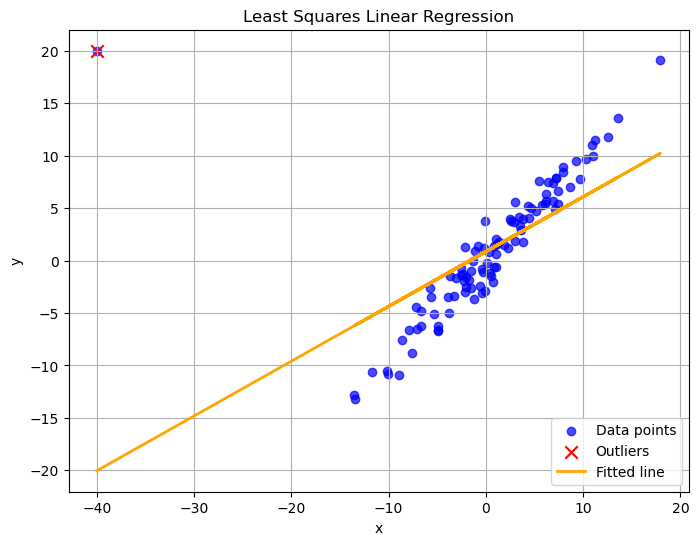

In [3]:
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression", outliers=outliers)

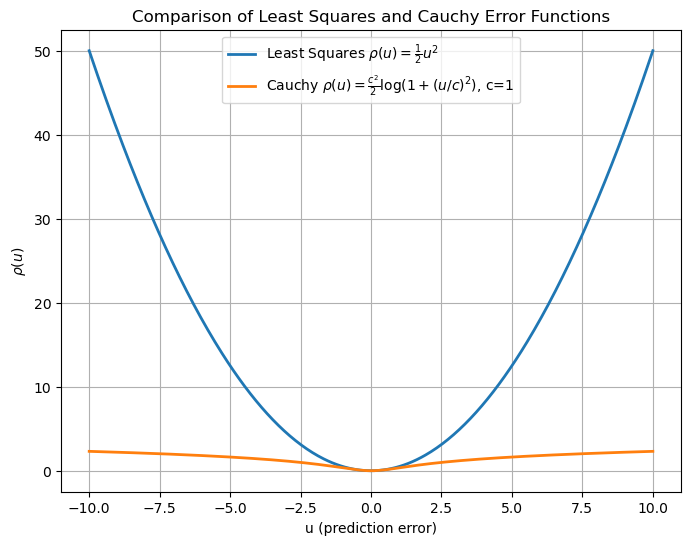

In [4]:
# Compare Least Squares vs Cauchy function
u = np.linspace(-10, 10, 400)
rho_ls = 0.5 * u**2
c = 1
rho_cauchy = 0.5 * (c**2) * np.log(1 + (u / c)**2)

plt.figure(figsize=(8, 6))
plt.plot(u, rho_ls, label=r'Least Squares $\rho(u) = \frac{1}{2}u^2$', linewidth=2)
plt.plot(u, rho_cauchy, label=r'Cauchy $\rho(u) = \frac{c^2}{2}\log(1+(u/c)^2)$, c=1', linewidth=2)
plt.xlabel('u (prediction error)')
plt.ylabel(r'$\rho(u)$')
plt.title('Comparison of Least Squares and Cauchy Error Functions')
plt.legend()
plt.grid(True)
plt.show()

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.9851, w1 = 0.2005
Cauchy Robust Fit (c=1): w0 = 0.9856, w1 = 0.2519


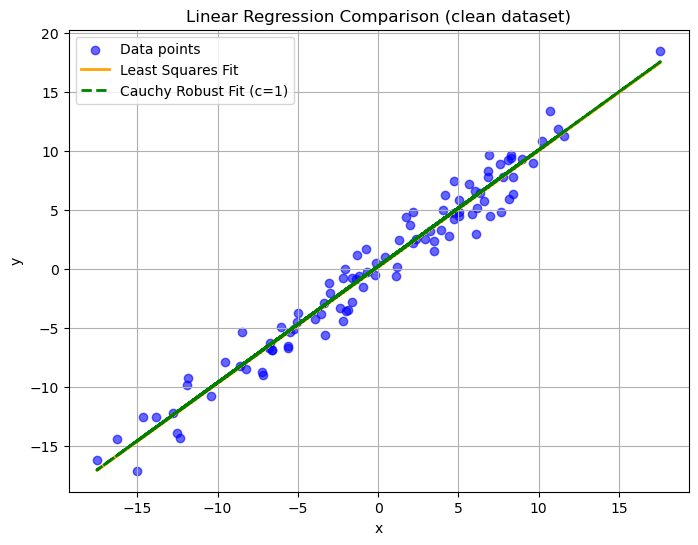

In [5]:
# Generate new clean dataset
points = generate_points(angle_deg=45, seed=0)


# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.6338, w1 = 0.6620
Cauchy Robust Fit (c=1): w0 = 0.9873, w1 = 0.2453


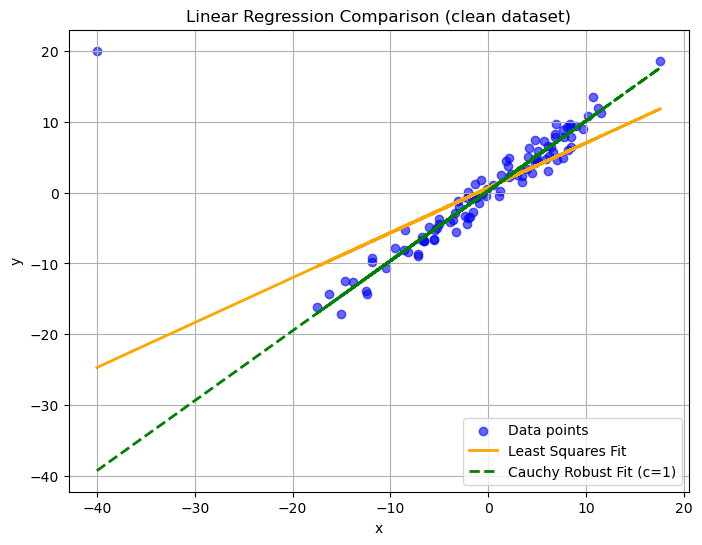

In [6]:
# Generate new clean dataset and perturbate it
points = generate_points(angle_deg=45, seed=0)
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

In [7]:
def gradient_descent(points, rho=lambda u: 0.5 * u**2, rho_prime=lambda u: u, 
                     alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent to find w0, w1 minimizing sum of rho(e_i)
    where e_i = w0*x_i + w1 - y_i.

    Parameters:
    - rho, rho_prime: error function and its derivative
    - alpha: learning rate
    - tol: stopping threshold for gradient norm
    - return_residuals: if True, returns (w0, w1, residuals)
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initialize parameters
    w0, w1 = 0.0, 0.0

    for i in range(max_iter):
        y_pred = w0 * x + w1
        e = y_pred - y

        # Compute gradients
        grad_w0 = np.sum(rho_prime(e) * x)
        grad_w1 = np.sum(rho_prime(e))

        grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
        if grad_norm < tol:
            break

        # Update parameters
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1

    if return_residuals:
        return w0, w1, e  # include residuals
    else:
        return w0, w1


def gradient_descent_robust(points, c=1, alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent using the Cauchy robust error function:
    rho(u) = (c^2 / 2) * log(1 + (u / c)^2)
    rho'(u) = u / (1 + (u / c)^2)
    """
    rho = lambda u: 0.5 * (c**2) * np.log(1 + (u / c)**2)
    rho_prime = lambda u: u / (1 + (u / c)**2)

    return gradient_descent(points, rho=rho, rho_prime=rho_prime,
                            alpha=alpha, max_iter=max_iter, tol=tol,
                            return_residuals=return_residuals)


Least Squares: w0 = 0.6338048698823504 w1 = 0.6620055963742805
Cauchy Robust (c=1): w0 = 0.9872955438750042 w1 = 0.24528152558361713


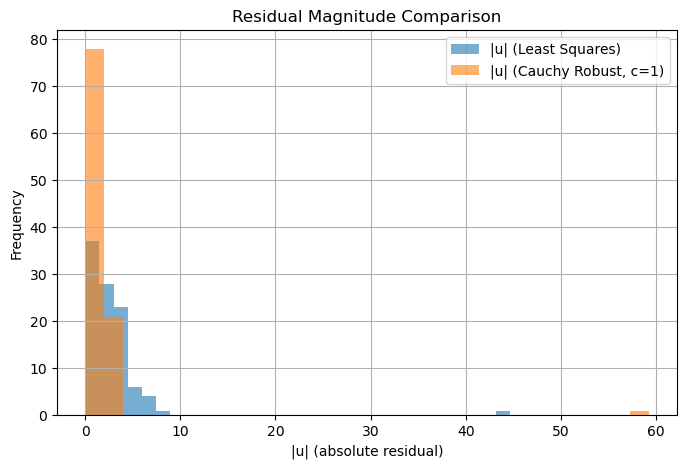

In [8]:
# Generate new dataset and introduce one outlier
points = generate_points(angle_deg=45, seed=0)
points[0] = [-40, 20]  # strong outlier

# Compute both regressions and residuals
w_ls, w1, u_ls = gradient_descent(points, return_residuals=True)
w_c, w2, u_cauchy = gradient_descent_robust(points, c=1, return_residuals=True)

# Print parameters
print("Least Squares: w0 =", w_ls, "w1 =", w1)
print("Cauchy Robust (c=1): w0 =", w_c, "w1 =", w2)

# Compare residuals
plt.figure(figsize=(8, 5))
plt.hist(np.abs(u_ls), bins=30, alpha=0.6, label='|u| (Least Squares)')
plt.hist(np.abs(u_cauchy), bins=30, alpha=0.6, label='|u| (Cauchy Robust, c=1)')
plt.xlabel('|u| (absolute residual)')
plt.ylabel('Frequency')
plt.title('Residual Magnitude Comparison')
plt.legend()
plt.grid(True)
plt.show()


c=1: Cauchy params w0=0.987296, w1=0.245282
c=100: Cauchy params w0=0.683095, w1=0.597268
c=0.01: Cauchy params w0=0.000266, w1=0.004465
c=0.001: Cauchy params w0=-0.000111, w1=0.000100


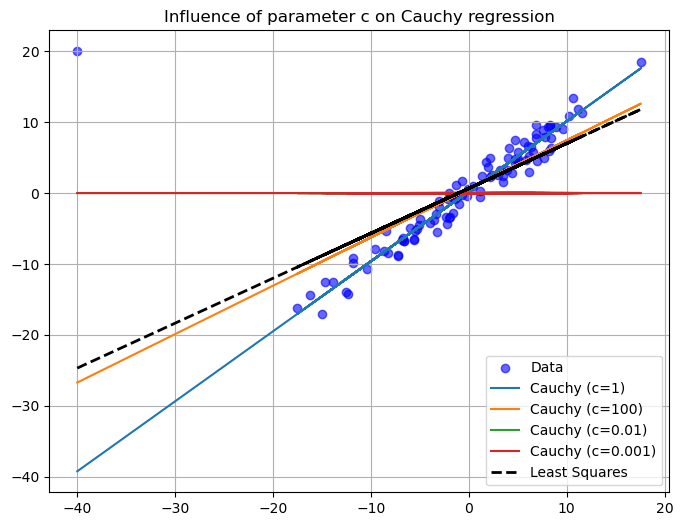

In [9]:
### EX 6 ###

import numpy as np

def linear_ls_closed_form(points):
    """
    Closed-form least squares solution for y = w0*x + w1
    using normal equations.
    Returns (w0, w1).
    """
    x = points[:, 0]
    y = points[:, 1]
    X = np.vstack([x, np.ones(len(x))]).T  # Design matrix
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w[0], w[1]


# Dataset with one outlier
points = generate_points(angle_deg=45, seed=0)
points[0] = [-40, 20]  # add one strong outlier

c_values = [1, 100, 0.01, 0.001]
w_ls = linear_ls_closed_form(points)

# Plot the fits for different c values
plt.figure(figsize=(8, 6))
x = points[:, 0]
y = points[:, 1]
plt.scatter(x, y, color='blue', alpha=0.6, label='Data')

for c in c_values:
    w_cauchy = gradient_descent_robust(points, c=c)
    y_cauchy = w_cauchy[0] * x + w_cauchy[1]
    plt.plot(x, y_cauchy, label=f'Cauchy (c={c})')
    print(f"c={c}: Cauchy params w0={w_cauchy[0]:.6f}, w1={w_cauchy[1]:.6f}")

y_ls = w_ls[0] * x + w_ls[1]
plt.plot(x, y_ls, color='black', linestyle='--', linewidth=2, label='Least Squares')
plt.legend(); plt.title("Influence of parameter c on Cauchy regression"); plt.grid(True)
plt.show()


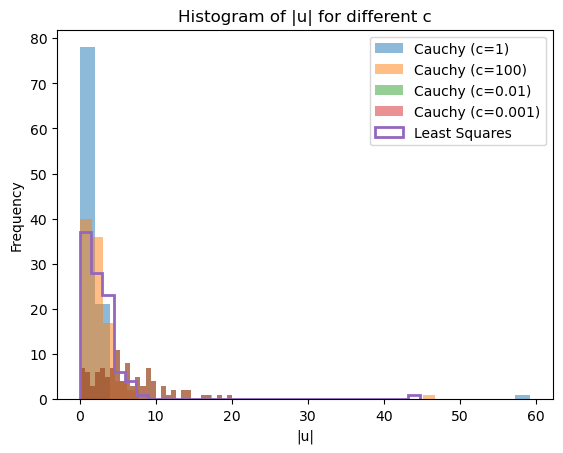

In [10]:
# Compare residual distributions for different c
for c in c_values:
    w_cauchy = gradient_descent_robust(points, c=c)
    y_pred = w_cauchy[0]*x + w_cauchy[1]
    e = y_pred - y
    plt.hist(np.abs(e), bins=30, alpha=0.5, label=f'Cauchy (c={c})')

# LS residuals for reference
y_pred_ls = w_ls[0]*x + w_ls[1]
e_ls = y_pred_ls - y
plt.hist(np.abs(e_ls), bins=30, histtype='step', linewidth=2, label='Least Squares')
plt.xlabel("|u|"); plt.ylabel("Frequency")
plt.legend(); plt.title("Histogram of |u| for different c"); plt.show()


k= 1: LS(0.6338,0.6620) | C1(0.9873,0.2453) | C0.01(0.0003,0.0045)
k= 2: LS(0.3954,0.9804) | C1(0.9908,0.2281) | C0.01(0.0001,0.0044)
k= 3: LS(0.2113,1.2967) | C1(0.9812,0.2556) | C0.01(-0.0001,0.0044)
k= 5: LS(-0.0178,1.6462) | C1(0.9745,0.2677) | C0.01(-0.0004,0.0042)
k=10: LS(-0.3092,2.2475) | C1(0.9615,0.3135) | C0.01(0.0078,-0.0002)
k=20: LS(-0.5549,2.4595) | C1(0.9537,0.3385) | C0.01(0.0052,0.0001)


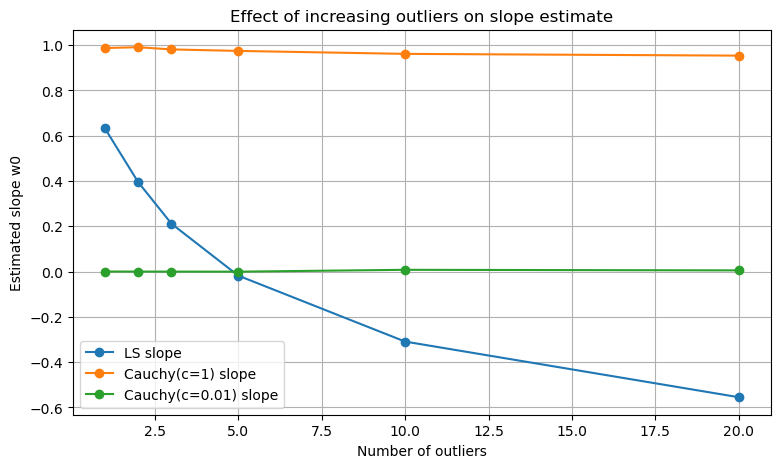

In [11]:
n_outliers_list = [1, 2, 3, 5, 10, 20]
results = []

for k in n_outliers_list:
    points_k = generate_points(angle_deg=45, seed=0)
    # introduce k outliers at the beginning
    for i in range(k):
        points_k[i] = [-40 - i*2, 20 + i*2]
    
    # Fit LS (closed form)
    w_ls_k = linear_ls_closed_form(points_k)
    # Fit Cauchy robust with two c values
    w_c1   = gradient_descent_robust(points_k, c=1)
    w_c001 = gradient_descent_robust(points_k, c=0.01)

    results.append((k, *w_ls_k, *w_c1, *w_c001))
    print(f"k={k:2d}: LS({w_ls_k[0]:.4f},{w_ls_k[1]:.4f}) | "
          f"C1({w_c1[0]:.4f},{w_c1[1]:.4f}) | "
          f"C0.01({w_c001[0]:.4f},{w_c001[1]:.4f})")

# Convert to array for plotting
results = np.array(results)
plt.figure(figsize=(9,5))
plt.plot(results[:,0], results[:,1], 'o-', label='LS slope')
plt.plot(results[:,0], results[:,3], 'o-', label='Cauchy(c=1) slope')
plt.plot(results[:,0], results[:,5], 'o-', label='Cauchy(c=0.01) slope')
plt.xlabel("Number of outliers")
plt.ylabel("Estimated slope w0")
plt.title("Effect of increasing outliers on slope estimate")
plt.legend(); plt.grid(True); plt.show()
